### This notebook generates figure 1 of the Shahbazi et al. 2026 paper

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import scipy.stats as stats
import statsmodels.api as sm
import cortico_cereb_connectivity.globals as gl
import cortico_cereb_connectivity.scripts.script_plotting_utils as plu
import cortico_cereb_connectivity.summarize as summarize

/home/UWO/ashahb7/Documents/cortico/lib/python3.8/site-packages/torch/cuda/__init__.py:128: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 11060). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at ../c10/cuda/CUDAFunctions.cpp:108.)
  return torch._C._cuda_getDeviceCount() > 0
/home/UWO/ashahb7/Documents/cortico/lib/python3.8/site-packages/torch/__init__.py:955: UserWarning: torch.set_default_tensor_type() is deprecated as of PyTorch 2.1, please use torch.set_default_dtype() and torch.set_default_device() as alternatives. (Triggered internally at ../torch/csrc/tensor/python_tensor.cpp:432.)
  _C._set_default_tensor_type(t)


#### import the .tsv files to plot

In [3]:
df_L2reg = pd.read_csv('../../tsv/L2reg_heatmap.tsv', sep='\t')
df_NNLS = pd.read_csv('../../tsv/NNLS_heatmap.tsv', sep='\t')
df_diff = pd.read_csv('../../tsv/Diff_heatmap.tsv', sep='\t')
df_all = pd.concat([df_L2reg, df_NNLS], axis=0).reset_index(drop=True)

pivot_L2reg = df_L2reg.pivot(index=['eval_dataset', 'eval_subj'], columns='train_dataset', values='R_eval_adj')
pivot_NNLS = df_NNLS.pivot(index=['eval_dataset', 'eval_subj'], columns='train_dataset', values='R_eval_adj')
pivot_all = df_all.pivot(index=["eval_dataset", "eval_subj"], 
                          columns=["train_dataset", "method"], values="R_eval_adj")
pivot_dataset = df_all.pivot_table(index="eval_dataset", columns=["train_dataset", "method"], values="R_eval_adj", aggfunc='mean')


ds_order = ["MDTB", "Language", "Social", "WMFS", "Demand", "Somatotopic", "Nishimoto", "IBC", "HCPur100"]

save_plots = False

#### ===========
####   PANEL A
#### ===========

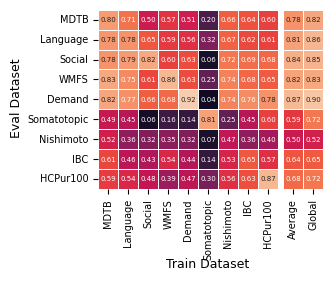

In [13]:
fig = plt.figure(figsize=(2.9, 2.4))
fig, ax1, ax2, cbar_ax = plu.plot_heatmap_annotate(df_L2reg, x_order=ds_order+["Average", "Global"], y_order=ds_order,
                                                   fig=fig, cbar=False, annot_kws={'fontsize': 5})
fig.supxlabel('Train Dataset', y=-0.22, fontsize=9)
fig.supylabel('Eval Dataset', x=-0.18, fontsize=9)
ax1.tick_params(labelsize=7)
ax2.tick_params(labelsize=7)

if save_plots:
    fig.savefig(gl.fig_dir + "/fig01_a.pdf", bbox_inches="tight", dpi=300)

In [15]:
pivot_L2reg['Same'] = [row[eval_ds] for (eval_ds, _), row in pivot_L2reg.iterrows()]
mean_same = pivot_L2reg['Same'].groupby(level='eval_dataset').mean()
print(f"Average of within-dataset correlations:\n{'num':<10} {'Mean':<10} {'SE':<10}")
print(f"{len(mean_same):<10} {mean_same.mean():<10.2f} {mean_same.sem():<10.2f}")

Average of within-dataset correlations:
num        Mean       SE        
9          0.78       0.05      


In [16]:
gen_MDTB = pivot_L2reg[pivot_L2reg.index.get_level_values('eval_dataset') != 'MDTB']['MDTB']
gen_Soma = pivot_L2reg[pivot_L2reg.index.get_level_values('eval_dataset') != 'Somatotopic']['Somatotopic']
gen_global = pivot_L2reg['Global']
print(f"Average generalization across other task sets:")
print(f"{'Dataset':<15} {'Num':<10} {'Mean':<10} {'SE':<10}")
print("=" * 45)
print(f"{'MDTB':<15} {gen_MDTB.count():<10} {gen_MDTB.mean():<10.2f} {gen_MDTB.sem():<10.2f}")
print(f"{'Somatotopic':<15} {gen_Soma.count():<10} {gen_Soma.mean():<10.2f} {gen_Soma.sem():<10.2f}")
print(f"{'Global':<15} {gen_global.count():<10} {gen_global.mean():<10.2f} {gen_global.sem():<10.2f}")

Average generalization across other task sets:
Dataset         Num        Mean       SE        
MDTB            168        0.70       0.02      
Somatotopic     184        0.19       0.01      
Global          192        0.79       0.02      


In [17]:
print(f"Same VS Average paired t-test results:")
print(f"\n{'Random effect':<15} {'dof':<10} {'t-stat':<10} {'p-value':<10} {'Sig':<10}")
print("=" * 55)

t_stat_sub, p_val_sub = stats.ttest_rel(pivot_L2reg['Same'], pivot_L2reg['Average'], nan_policy='omit', alternative='greater')
print(f"{'Subject':<15} {len(pivot_L2reg['Same'])-1:<10} {t_stat_sub:<10.2f} {p_val_sub:<10.2e} {'Yes' if p_val_sub < 0.05 else 'No':<10}")

mean_same = pivot_L2reg['Same'].groupby(level='eval_dataset').mean()
mean_average = pivot_L2reg['Average'].groupby(level='eval_dataset').mean()
t_stat_ds, p_val_ds = stats.ttest_rel(mean_same, mean_average, nan_policy='omit', alternative='greater')
print(f"{'Dataset':<15} {len(mean_same)-1:<10} {t_stat_ds:<10.2f} {p_val_ds:<10.2e} {'Yes' if p_val_ds < 0.05 else 'No':<10}")

Same VS Average paired t-test results:

Random effect   dof        t-stat     p-value    Sig       
Subject         191        7.62       5.82e-13   Yes       
Dataset         8          1.65       6.91e-02   No        


In [27]:
print(f"Average VS Best paired t-test results:")
print(f"\n{'Random effect':<15} {'dof':<10} {'t-stat':<10} {'p-value':<10} {'Sig':<10}")
print("=" * 55)

best_ds_map = {}
for ds in ds_order:
    df_average = pivot_L2reg[pivot_L2reg.index.get_level_values('eval_dataset') == ds]["Average"]
    # find best dataset
    best_ds = (
        df_L2reg[
            (df_L2reg['train_dataset'].isin(ds_order)) &
            (df_L2reg['train_dataset'] != ds) &
            (df_L2reg['eval_dataset'] == ds)
        ]
        .groupby('train_dataset')['R_eval_adj']
        .mean()
        .idxmax()
    )
    best_ds_map[ds] = best_ds

eval_ds = pivot_L2reg.index.get_level_values('eval_dataset')
pivot_L2reg['Best'] = pivot_L2reg.to_numpy()[
    np.arange(len(pivot_L2reg)),
    pivot_L2reg.columns.get_indexer(eval_ds.map(best_ds_map))
]

t_stat_sub, p_val_sub = stats.ttest_rel(pivot_L2reg['Average'], pivot_L2reg['Best'], nan_policy='omit', alternative='greater')
print(f"{'Subject':<15} {len(pivot_L2reg['Best'])-1:<10} {t_stat_sub:<10.2f} {p_val_sub:<10.2e} {'Yes' if p_val_sub < 0.05 else 'No':<10}")

mean_average = pivot_L2reg['Average'].groupby(level='eval_dataset').mean()
mean_best = pivot_L2reg['Best'].groupby(level='eval_dataset').mean()
t_stat_ds, p_val_ds = stats.ttest_rel(mean_average, mean_best, nan_policy='omit', alternative='greater')
print(f"{'Dataset':<15} {len(mean_best)-1:<10} {t_stat_ds:<10.2f} {p_val_ds:<10.2e} {'Yes' if p_val_ds < 0.05 else 'No':<10}")

Average VS Best paired t-test results:

Random effect   dof        t-stat     p-value    Sig       
Subject         191        8.50       2.66e-15   Yes       
Dataset         8          2.31       2.49e-02   Yes       


In [33]:
print(f"Global VS Average paired t-test results:")
print(f"\n{'Random effect':<15} {'dof':<10} {'t-stat':<10} {'p-value':<10} {'Sig':<10}")
print("=" * 55)

t_stat_sub, p_val_sub = stats.ttest_rel(pivot_L2reg['Global'], pivot_L2reg['Average'], nan_policy='omit', alternative='greater')
print(f"{'Subject':<15} {len(pivot_L2reg['Global'])-1:<10} {t_stat_sub:<10.2f} {p_val_sub:<10.2e} {'Yes' if p_val_sub < 0.05 else 'No':<10}")

mean_global = pivot_L2reg['Global'].groupby(level='eval_dataset').mean()
mean_average = pivot_L2reg['Average'].groupby(level='eval_dataset').mean()
t_stat, p_val = stats.ttest_rel(mean_global, mean_average, nan_policy='omit', alternative='greater')
print(f"{'Dataset':<15} {len(mean_global)-1:<10} {t_stat:<10.2f} {p_val:<10.2e} {'Yes' if p_val < 0.05 else 'No':<10}")

Global VS Average paired t-test results:

Random effect   dof        t-stat     p-value    Sig       
Subject         191        9.94       2.43e-19   Yes       
Dataset         8          3.05       7.91e-03   Yes       


#### ===========
####   PANEL B
#### ===========

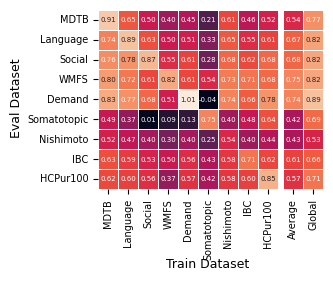

In [12]:
fig = plt.figure(figsize=(2.9, 2.4))
fig, ax1, ax2, cbar_ax = plu.plot_heatmap_annotate(df_NNLS, x_order=ds_order+["Average", "Global"], y_order=ds_order,
                                                   fig=fig, cbar=False, annot_kws={'fontsize': 5})
fig.supxlabel('Train Dataset', y=-0.22, fontsize=9)
fig.supylabel('Eval Dataset', x=-0.18, fontsize=9)
ax1.tick_params(labelsize=7)
ax2.tick_params(labelsize=7)

if save_plots:
    fig.savefig(gl.fig_dir + "/fig01_b.pdf", bbox_inches="tight", dpi=300)

In [30]:
pivot_NNLS['Same'] = [row[eval_ds] for (eval_ds, _), row in pivot_NNLS.iterrows()]

print(f"Same VS Average paired t-test results:")
print(f"\n{'Random effect':<15} {'dof':<10} {'t-stat':<10} {'p-value':<10} {'Sig':<10}")
print("=" * 55)

t_stat_sub, p_val_sub = stats.ttest_rel(pivot_NNLS['Same'], pivot_NNLS['Average'], nan_policy='omit', alternative='greater')
print(f"{'Subject':<15} {len(pivot_NNLS['Same'])-1:<10} {t_stat_sub:<10.2f} {p_val_sub:<10.2e} {'Yes' if p_val_sub < 0.05 else 'No':<10}")

mean_same = pivot_NNLS['Same'].groupby(level='eval_dataset').mean()
mean_average = pivot_NNLS['Average'].groupby(level='eval_dataset').mean()
t_stat_ds, p_val_ds = stats.ttest_rel(mean_same, mean_average, nan_policy='omit', alternative='greater')
print(f"{'Dataset':<15} {len(mean_same)-1:<10} {t_stat_ds:<10.2f} {p_val_ds:<10.2e} {'Yes' if p_val_ds < 0.05 else 'No':<10}")

Same VS Average paired t-test results:

Random effect   dof        t-stat     p-value    Sig       
Subject         191        23.83      2.07e-59   Yes       
Dataset         8          6.31       1.16e-04   Yes       


In [54]:
print(f"Global VS Best paired t-test results:")
print(f"\n{'Random effect':<15} {'dof':<10} {'t-stat':<10} {'p-value':<10} {'Sig':<10}")
print("=" * 55)

best_ds_map = {}
for ds in ds_order:
    # find best dataset
    best_ds = (
        df_NNLS[
            (df_NNLS['train_dataset'].isin(ds_order)) &
            (df_NNLS['train_dataset'] != ds) &
            (df_NNLS['eval_dataset'] == ds)
        ]
        .groupby('train_dataset')['R_eval_adj']
        .mean()
        .idxmax()
    )
    best_ds_map[ds] = best_ds

eval_ds = pivot_NNLS.index.get_level_values('eval_dataset')
pivot_NNLS['Best'] = pivot_NNLS.to_numpy()[
    np.arange(len(pivot_NNLS)),
    pivot_NNLS.columns.get_indexer(eval_ds.map(best_ds_map))
]

t_stat_sub, p_val_sub = stats.ttest_rel(pivot_NNLS['Global'], pivot_NNLS['Best'], nan_policy='omit', alternative='greater')
print(f"{'Subject':<15} {len(pivot_NNLS['Best'])-1:<10} {t_stat_sub:<10.2f} {p_val_sub:<10.2e} {'Yes' if p_val_sub < 0.05 else 'No':<10}")

mean_global = pivot_NNLS['Global'].groupby(level='eval_dataset').mean()
mean_best = pivot_NNLS['Best'].groupby(level='eval_dataset').mean()
t_stat_ds, p_val_ds = stats.ttest_rel(mean_global, mean_best, nan_policy='omit', alternative='greater')
print(f"{'Dataset':<15} {len(mean_best)-1:<10} {t_stat_ds:<10.2f} {p_val_ds:<10.2e} {'Yes' if p_val_ds < 0.05 else 'No':<10}")

Global VS Best paired t-test results:

Random effect   dof        t-stat     p-value    Sig       
Subject         191        17.14      8.39e-41   Yes       
Dataset         8          4.83       6.55e-04   Yes       


In [34]:
print(f"Global VS Average paired t-test results:")
print(f"\n{'Random effect':<15} {'dof':<10} {'t-stat':<10} {'p-value':<10} {'Sig':<10}")
print("=" * 55)

t_stat_sub, p_val_sub = stats.ttest_rel(pivot_NNLS['Global'], pivot_NNLS['Average'], nan_policy='omit', alternative='greater')
print(f"{'Subject':<15} {len(pivot_NNLS['Global'])-1:<10} {t_stat_sub:<10.2f} {p_val_sub:<10.2e} {'Yes' if p_val_sub < 0.05 else 'No':<10}")

mean_global = pivot_NNLS['Global'].groupby(level='eval_dataset').mean()
mean_average = pivot_NNLS['Average'].groupby(level='eval_dataset').mean()
t_stat, p_val = stats.ttest_rel(mean_global, mean_average, nan_policy='omit', alternative='greater')
print(f"{'Dataset':<15} {len(mean_global)-1:<10} {t_stat:<10.2f} {p_val:<10.2e} {'Yes' if p_val < 0.05 else 'No':<10}")

Global VS Average paired t-test results:

Random effect   dof        t-stat     p-value    Sig       
Subject         191        22.01      1.40e-54   Yes       
Dataset         8          6.36       1.09e-04   Yes       


#### ===========
####   PANEL C
#### ===========

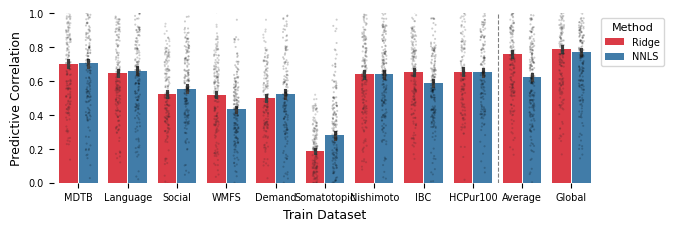

In [9]:
df_all = pd.concat([df_L2reg[df_L2reg.train_dataset != df_L2reg.eval_dataset],
                    df_NNLS[df_NNLS.train_dataset != df_NNLS.eval_dataset]]).reset_index(drop=True)

plt.figure(figsize=(7,2.2))
ax = plu.plot_barplot_with_error(df_all)
ax.set_ylim(0,1)
ax.set_ylabel('Predictive Correlation', fontsize=9)
ax.set_xlabel('Train Dataset', fontsize=9)
label_map = {'L2reg': 'Ridge', 'NNLS': 'NNLS'}
handles, labels = ax.get_legend_handles_labels()
new_labels = [label_map[l] for l in labels]
ax.legend(handles, new_labels, title='Method', bbox_to_anchor=(1.0, 1), loc='upper left', title_fontsize=8, fontsize=7)
ax.axvline(x=8.5, color='gray', linestyle='--', linewidth=0.8)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
sns.despine(left=True, bottom=True)
ax.tick_params(labelsize=7)

if save_plots:
    plt.savefig(gl.fig_dir + "/fig01_c.pdf", bbox_inches="tight", dpi=300)

In [45]:
print(f"Ridge VS NNLS paired t-test results:")
print(f"\n{'Dataset':<15} {'dof':<10} {'t-stat':<10} {'p-value':<10} {'Winner':<10}")
print("=" * 55)

for ds in ds_order:
    df_sub_L2 = pivot_all[pivot_all.index.get_level_values("eval_dataset") != ds][(ds, "L2reg")]
    df_sub_NNLS = pivot_all[pivot_all.index.get_level_values("eval_dataset") != ds][(ds, "NNLS")]

    t_stat, p_val = stats.ttest_rel(df_sub_L2, df_sub_NNLS, nan_policy='omit')
    winner = '----' if p_val > 0.05 else ('Ridge' if t_stat > 0 else 'NNLS')
    print(f"{ds:<15} {len(df_sub_L2)-1:<10} {t_stat:<10.2f} {p_val:<10.2e} {winner:<10}")

print("-" * 55)
for ds in ["Average", "Global"]:
    df_sub_L2 = pivot_all[(ds, "L2reg")]
    df_sub_NNLS = pivot_all[(ds, "NNLS")]

    t_stat, p_val = stats.ttest_rel(df_sub_L2, df_sub_NNLS, nan_policy='omit', alternative='two-sided')
    winner = '----' if p_val > 0.05 else ('Ridge' if t_stat > 0 else 'NNLS')
    print(f"{ds:<15} {len(df_sub_L2)-1:<10} {t_stat:<10.2f} {p_val:<10.2e} {winner:<10}")

    df_ds_L2 = pivot_all[(ds, "L2reg")].groupby(level='eval_dataset').mean()
    df_ds_NNLS = pivot_all[(ds, "NNLS")].groupby(level='eval_dataset').mean()

    t_stat, p_val = stats.ttest_rel(df_ds_L2, df_ds_NNLS, nan_policy='omit', alternative='two-sided')
    winner = '----' if p_val > 0.05 else ('Ridge' if t_stat > 0 else 'NNLS')
    print(f"{ds:<15} {len(df_ds_L2)-1:<10} {t_stat:<10.2f} {p_val:<10.2e} {winner:<10}")

df_ds_diff = df_ds_L2 - df_ds_NNLS
print(f"\nMean difference between Global Ridge and Global NNLS: {df_ds_diff.mean():.2f} ± {df_ds_diff.sem():.2f}")


Ridge VS NNLS paired t-test results:

Dataset         dof        t-stat     p-value    Winner    
MDTB            167        -0.31      7.55e-01   ----      
Language        174        -0.95      3.42e-01   ----      
Social          169        -4.51      1.23e-05   NNLS      
WMFS            175        10.39      5.26e-20   Ridge     
Demand          154        -1.53      1.27e-01   ----      
Somatotopic     183        -6.17      4.39e-09   NNLS      
Nishimoto       185        -0.01      9.89e-01   ----      
IBC             179        5.79       3.12e-08   Ridge     
HCPur100        141        0.22       8.30e-01   ----      
-------------------------------------------------------
Average         191        13.86      1.07e-30   Ridge     
Average         8          6.27       2.40e-04   Ridge     
Global          191        2.71       7.36e-03   Ridge     
Global          8          2.39       4.42e-02   Ridge     

Mean difference between Global Ridge and Global NNLS: 0.02 ± 0.01

In [8]:
print(f"Ridge VS NNLS paired t-test results (Dataset):")
print(f"\n{'Dataset':<15} {'dof':<10} {'t-stat':<10} {'p-value':<10} {'Winner':<10}")
print("=" * 55)
for ds in ["Average", "Global"]:
    df_sub_L2 = pivot_dataset[(ds, "L2reg")]
    df_sub_NNLS = pivot_dataset[(ds, "NNLS")]

    t_stat, p_val = stats.ttest_rel(df_sub_L2, df_sub_NNLS, nan_policy='omit', alternative='two-sided')
    winner = '----' if p_val > 0.05 else ('Ridge' if t_stat > 0 else 'NNLS')
    print(f"{ds:<15} {len(df_sub_L2)-1:<10} {t_stat:<10.3f} {p_val:<10.4f} {winner:<10}")

Ridge VS NNLS paired t-test results (Dataset):

Dataset         dof        t-stat     p-value    Winner    
Average         8          6.271      0.0002     Ridge     
Global          8          2.385      0.0442     Ridge     


In [13]:
# Repeated Measurements
df_global = df_all[df_all['train_dataset'] == 'Global'].copy()
df_global["subject_nested"] = df_global['eval_dataset'].astype(str) + "_" + df_global['eval_subj'].astype(str)

# Fit
model = sm.formula.mixedlm(
    formula="R_eval_adj ~ method",
    data=df_global,
    groups=df_global['eval_dataset'],                           # random intercept per dataset
    vc_formula={"subject_nested": "0 + C(subject_nested)"}      # random intercept per subject within dataset
)

result = model.fit(method='lbfgs')
print(result.summary())

            Mixed Linear Model Regression Results
Model:               MixedLM  Dependent Variable:  R_eval_adj
No. Observations:    384      Method:              REML      
No. Groups:          9        Scale:               0.0045    
Min. group size:     12       Log-Likelihood:      169.1123  
Max. group size:     100      Converged:           Yes       
Mean group size:     42.7                                    
-------------------------------------------------------------
                   Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------------
Intercept           0.792    0.018 43.551 0.000  0.756  0.827
method[T.NNLS]     -0.019    0.007 -2.709 0.007 -0.032 -0.005
subject_nested Var  0.059    0.132                           

